# Sofia Urban Heat Island Interactive Map (2020-2024)

This notebook creates an interactive heatmap visualization of Sofia's temperature data across different districts.

## 1. Import Required Libraries

In [7]:
import pandas as pd
import folium
from folium.plugins import HeatMap
from datetime import datetime
import numpy as np
from IPython.display import HTML, display
import ipywidgets
from ipywidgets import interact, DatePicker, RadioButtons, FloatSlider, HBox, VBox

## 2. Load the Data

In [8]:
# Load the Sofia heat dataset
df = pd.read_csv('sofia_heat_всички_2020-2024.csv')
df['date'] = pd.to_datetime(df['date'])

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (73080, 7)
Date range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00

First few rows:


,district,date,temp_max,temp_min,temp_mean,lat,lon
0,Bancя,2020-01-01,3.5,-3.4,-0.4,42.7272,23.2458
1,Bancя,2020-01-02,2.5,-3.8,-1.5,42.7272,23.2458
2,Bancя,2020-01-03,6.8,-3.3,0.4,42.7272,23.2458
3,Bancя,2020-01-04,9.8,-1.7,2.6,42.7272,23.2458
4,Bancя,2020-01-05,2.3,-1.1,1.1,42.7272,23.2458


## 3. Define Color Mapping Function

In [9]:
def get_color(temp, temp_cold, temp_cool, temp_warm):
    """Assign color based on temperature thresholds"""
    if pd.isna(temp):
        return '#CCCCCC'  # Gray for missing data
    elif temp <= temp_cold:
        return '#00AA00'  # Green
    elif temp <= temp_cool:
        return '#FFFF00'  # Yellow
    elif temp <= temp_warm:
        return '#FFA500'  # Orange
    else:
        return '#FF0000'  # Red

print("Color mapping function defined")
print("🟢 Green = Cold")
print("🟡 Yellow = Cool")
print("🟠 Orange = Warm")
print("🔴 Red = Hot")

Color mapping function defined
🟢 Green = Cold
🟡 Yellow = Cool
🟠 Orange = Warm
🔴 Red = Hot


## 4. Define Map Creation Function

In [10]:
def create_temperature_heatmap(selected_date, temp_cold=5, temp_cool=15, temp_warm=25):
    """
    Create an interactive heatmap for the selected date
    
    Parameters:
    - selected_date: datetime object or string in YYYY-MM-DD format
    - temp_cold: temperature threshold for green (°C)
    - temp_cool: temperature threshold for yellow (°C)
    - temp_warm: temperature threshold for orange (°C)
    """
    
    # Convert to string if needed
    if hasattr(selected_date, 'strftime'):
        date_str = selected_date.strftime('%Y-%m-%d')
    else:
        date_str = str(selected_date)
    
    # Filter data for selected date
    day_data = df[df['date'].dt.strftime('%Y-%m-%d') == date_str].copy()
    
    if day_data.empty:
        print(f"No data available for {selected_date}")
        return None
    
    # Sofia center coordinates
    sofia_center = [42.6977, 23.3219]
    m = folium.Map(location=sofia_center, zoom_start=11, tiles="OpenStreetMap")
    
    # Normalize temperature for heatmap intensity
    min_temp = day_data['temp_mean'].min()
    max_temp = day_data['temp_mean'].max()
    
    # Prepare data for heatmap
    heat_data = []
    for _, row in day_data.iterrows():
        lat = row['lat']
        lon = row['lon']
        temp = row['temp_mean']
        
        # Normalize temperature to intensity (0-1)
        if max_temp > min_temp:
            intensity = (temp - min_temp) / (max_temp - min_temp)
        else:
            intensity = 0.5
        
        heat_data.append([lat, lon, intensity])
    
    # Add heatmap layer
    HeatMap(heat_data, 
            radius=30, 
            blur=25, 
            max_zoom=1, 
            gradient={0.2: 'green', 0.5: 'yellow', 0.7: 'orange', 1.0: 'red'}
    ).add_to(m)
    
    # Add district markers with information
    for _, row in day_data.iterrows():
        district = row['district']
        temp = row['temp_mean']
        lat = row['lat']
        lon = row['lon']
        color = get_color(temp, temp_cold, temp_cool, temp_warm)
        
        # Create popup text
        popup_text = f"""
        <b>{district}</b><br>
        Date: {date_str}<br>
        Avg Temp: {temp:.1f}°C<br>
        Max Temp: {row['temp_max']:.1f}°C<br>
        Min Temp: {row['temp_min']:.1f}°C
        """
        
        folium.CircleMarker(
            location=[lat, lon],
            radius=8,
            popup=folium.Popup(popup_text, max_width=250),
            color=color,
            fill=True,
            fillColor=color,
            fillOpacity=0.9,
            weight=2,
            opacity=0.9
        ).add_to(m)
    
    return m, day_data

print("Map creation function defined")

Map creation function defined


## 5. Interactive Visualization

In [11]:
# Get date range from data
min_date = df['date'].min().date()
max_date = df['date'].max().date()

# Create widgets
date_picker = DatePicker(
    value=pd.Timestamp('2023-06-15').date(),
    description='Select Date:',
    disabled=False,
    min=min_date,
    max=max_date
)

temp_cold_slider = FloatSlider(value=5, min=-10, max=20, step=1, description='Green (°C):')
temp_cool_slider = FloatSlider(value=15, min=0, max=25, step=1, description='Yellow (°C):')
temp_warm_slider = FloatSlider(value=25, min=10, max=40, step=1, description='Orange (°C):')

# Display controls
print(f"Date range: {min_date} to {max_date}")
print("\nAdjust parameters below and the map will update:")
display(date_picker)
display(temp_cold_slider)
display(temp_cool_slider)
display(temp_warm_slider)

Date range: 2020-01-01 to 2024-12-31

Adjust parameters below and the map will update:


DatePicker(value=datetime.date(2023, 6, 15), description='Select Date:', max=datetime.date(2024, 12, 31), min=…

FloatSlider(value=5.0, description='Green (°C):', max=20.0, min=-10.0, step=1.0)

FloatSlider(value=15.0, description='Yellow (°C):', max=25.0, step=1.0)

FloatSlider(value=25.0, description='Orange (°C):', max=40.0, min=10.0, step=1.0)

## 6. Display the Heatmap

In [12]:
# Create and display the map
selected_date = date_picker.value
m, day_data = create_temperature_heatmap(
    selected_date,
    temp_cold=temp_cold_slider.value,
    temp_cool=temp_cool_slider.value,
    temp_warm=temp_warm_slider.value
)

if m is not None:
    # Save and display the map
    m.save('sofia_heatmap_temp.html')
    display(m)

## 7. Display Statistics

In [13]:
if day_data is not None:
    print(f"\n📊 Statistics for {date_picker.value}:")
    print(f"\nAverage Temperature: {day_data['temp_mean'].mean():.1f}°C")
    print(f"Maximum Temperature: {day_data['temp_max'].max():.1f}°C")
    print(f"Minimum Temperature: {day_data['temp_min'].min():.1f}°C")
    print(f"Number of Districts: {len(day_data)}")
    
    # Display district data sorted by temperature
    print("\n📋 District Temperature Data (sorted by average temperature):")
    display_df = day_data[['district', 'temp_mean', 'temp_max', 'temp_min']].copy()
    display_df.columns = ['District', 'Avg Temp (°C)', 'Max Temp (°C)', 'Min Temp (°C)']
    display_df = display_df.sort_values('Avg Temp (°C)', ascending=False)
    display(display_df)


📊 Statistics for 2023-06-15:

Average Temperature: 17.8°C
Maximum Temperature: 22.4°C
Minimum Temperature: 11.6°C
Number of Districts: 40

📋 District Temperature Data (sorted by average temperature):


,District,Avg Temp (°C),Max Temp (°C),Min Temp (°C)
46925,Кремиковци,18.7,22.4,14.6
45830,Искър,18.3,21.5,14.8
57145,Суха река,18.3,21.5,14.8
54955,Малашевци,18.3,21.5,14.8
50210,Подуяне,18.3,21.5,14.8
49115,Оборище,18.3,21.5,14.8
48750,Нови Искър,18.3,21.3,14.6
50940,Слатина,18.3,21.5,14.8
57510,Хаджи Димитър,18.3,21.5,14.8
53495,Дружба,18.3,21.5,14.8


## 8. Color Scale Legend

In [14]:
print("\n📊 Temperature Color Scale:")
print(f"\n🟢 GREEN (Cold): ≤ {temp_cold_slider.value:.0f}°C")
print(f"🟡 YELLOW (Cool): {temp_cold_slider.value:.0f} - {temp_cool_slider.value:.0f}°C")
print(f"🟠 ORANGE (Warm): {temp_cool_slider.value:.0f} - {temp_warm_slider.value:.0f}°C")
print(f"🔴 RED (Hot): > {temp_warm_slider.value:.0f}°C")


📊 Temperature Color Scale:

🟢 GREEN (Cold): ≤ 5°C
🟡 YELLOW (Cool): 5 - 15°C
🟠 ORANGE (Warm): 15 - 25°C
🔴 RED (Hot): > 25°C


## 9. Analysis: Hottest and Coldest Districts

In [15]:
if day_data is not None:
    print(f"\n🔥 Top 5 Hottest Districts on {date_picker.value}:")
    hottest = day_data.nlargest(5, 'temp_mean')[['district', 'temp_mean']]
    for idx, (_, row) in enumerate(hottest.iterrows(), 1):
        print(f"{idx}. {row['district']}: {row['temp_mean']:.1f}°C")
    
    print(f"\n❄️  Top 5 Coldest Districts on {date_picker.value}:")
    coldest = day_data.nsmallest(5, 'temp_mean')[['district', 'temp_mean']]
    for idx, (_, row) in enumerate(coldest.iterrows(), 1):
        print(f"{idx}. {row['district']}: {row['temp_mean']:.1f}°C")


🔥 Top 5 Hottest Districts on 2023-06-15:
1. Кремиковци: 18.7°C
2. Искър: 18.3°C
3. Нови Искър: 18.3°C
4. Оборище: 18.3°C
5. Подуяне: 18.3°C

❄️  Top 5 Coldest Districts on 2023-06-15:
1. Бояна: 15.1°C
2. Горна баня: 16.7°C
3. Витоша: 16.9°C
4. Красна поляна: 17.0°C
5. Овча купел: 17.0°C


## 10. Temporal Analysis: Temperature Trends

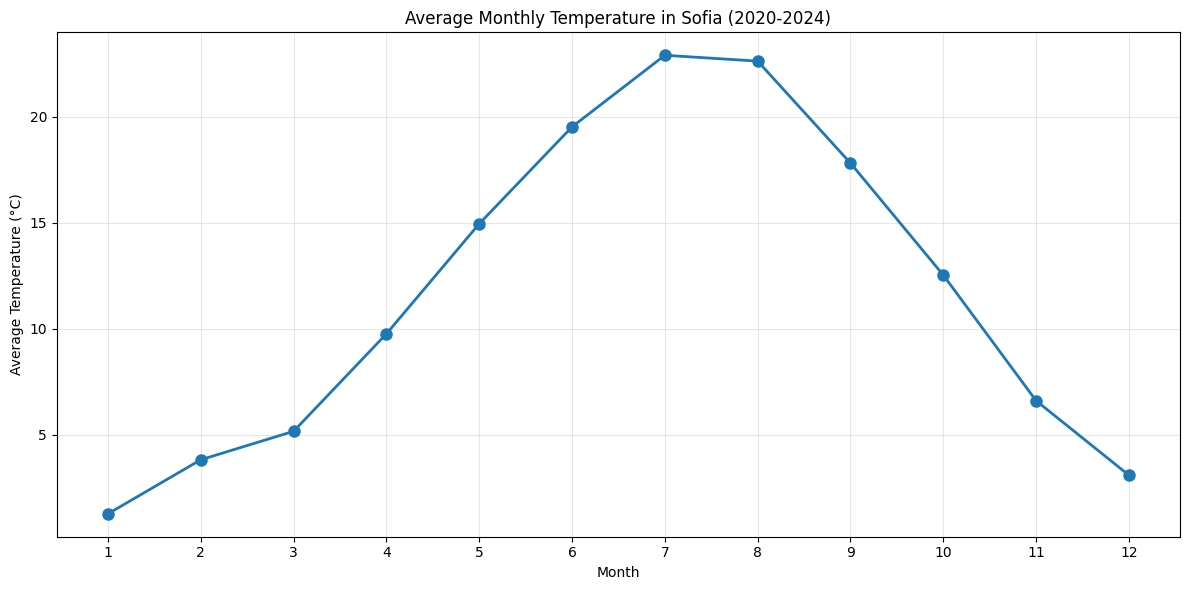

Monthly average temperatures have been calculated from the entire dataset.


In [16]:
import matplotlib.pyplot as plt

# Plot average temperature by month across all years
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

monthly_avg = df.groupby('month')['temp_mean'].mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, markersize=8)
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.title('Average Monthly Temperature in Sofia (2020-2024)')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

print("Monthly average temperatures have been calculated from the entire dataset.")

## 11. Summer Comparison: 2020 vs 2024

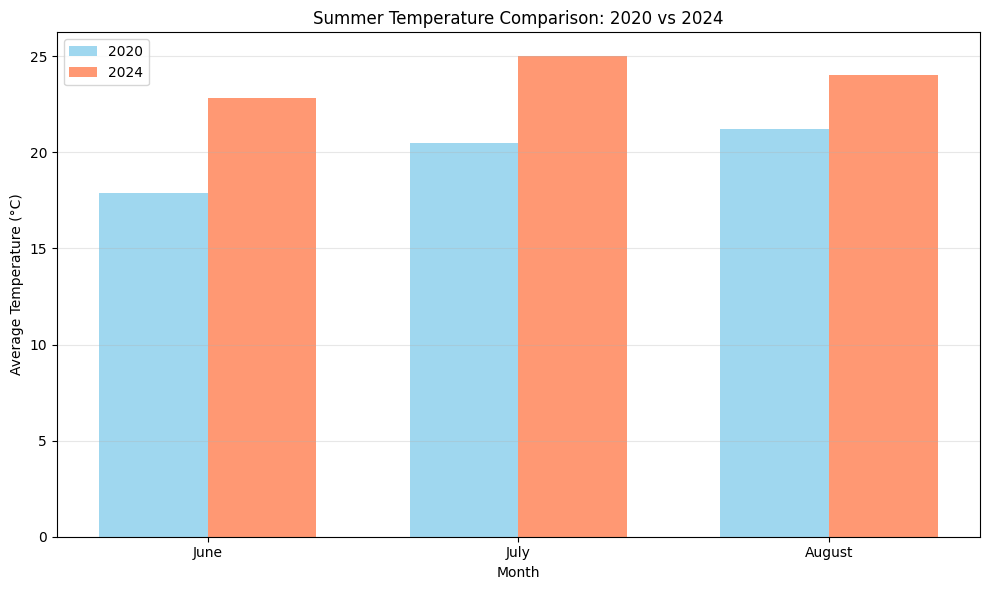

☀️  SUMMER COMPARISON (2020 vs 2024)

2020 Summer Temperatures:
  June: 17.9°C
  July: 20.5°C
  August: 21.2°C

2024 Summer Temperatures:
  June: 22.8°C
  July: 25.0°C
  August: 24.0°C

Temperature Difference (2024 - 2020):
  June: +4.9°C
  July: +4.5°C
  August: +2.8°C


In [17]:
# Filter summer months (June, July, August) for 2020 and 2024
summer_months = [6, 7, 8]

# Get 2020 and 2024 summer data
df_2020_summer = df[(df['year'] == 2020) & (df['month'].isin(summer_months))].groupby('month')['temp_mean'].mean()
df_2024_summer = df[(df['year'] == 2024) & (df['month'].isin(summer_months))].groupby('month')['temp_mean'].mean()

# Create comparison plot
plt.figure(figsize=(10, 6))
months_labels = ['June', 'July', 'August']
x = np.arange(len(months_labels))
width = 0.35

plt.bar(x - width/2, df_2020_summer.values, width, label='2020', color='skyblue', alpha=0.8)
plt.bar(x + width/2, df_2024_summer.values, width, label='2024', color='coral', alpha=0.8)

plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.title('Summer Temperature Comparison: 2020 vs 2024')
plt.xticks(x, months_labels)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print statistics
print("☀️  SUMMER COMPARISON (2020 vs 2024)")
print("\n2020 Summer Temperatures:")
for month, temp in zip(months_labels, df_2020_summer.values):
    print(f"  {month}: {temp:.1f}°C")

print("\n2024 Summer Temperatures:")
for month, temp in zip(months_labels, df_2024_summer.values):
    print(f"  {month}: {temp:.1f}°C")

print("\nTemperature Difference (2024 - 2020):")
for month, temp_2020, temp_2024 in zip(months_labels, df_2020_summer.values, df_2024_summer.values):
    diff = temp_2024 - temp_2020
    sign = "+" if diff > 0 else ""
    print(f"  {month}: {sign}{diff:.1f}°C")